In [1]:
import tensorflow as tf
from keras.src.regularizers import regularizers
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from tensorflow import keras

I0000 00:00:1788102794.078365    4271 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788102794.084100    4271 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788102794.122048    4271 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788102795.516841    4271 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [2]:
dataset_path = "./datasets/flower_photos/"

In [3]:
IMG_SIZE = 224
IMG_CHANNELS = 3
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 10
CLASS_NAMES = ["daisy", "dandelion", "roses", "sunflowers", "tulips"]

In [4]:
# creating an tensorflow dataset (including image size and batch)
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    shuffle = True,
    image_size = (IMG_SIZE,IMG_SIZE), # height and width
    batch_size = BATCH_SIZE,
)

Found 3670 files belonging to 5 classes.


E0000 00:00:1788102796.413315    4271 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1788102796.413748    4338 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1788102796.756933    4271 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [5]:
print(dataset)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [6]:
class_names = dataset.class_names
class_names

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

In [7]:
dataset.take(1) # this return the first bacth from the dataset

<_TakeDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [8]:
for image_batch, labels_batch in dataset.take(1):
    print(image_batch.shape)
    print(labels_batch.numpy())

(32, 224, 224, 3)
[2 4 0 2 1 3 4 4 0 3 3 1 3 1 1 3 1 3 3 4 0 1 4 0 0 1 1 1 2 2 2 3]


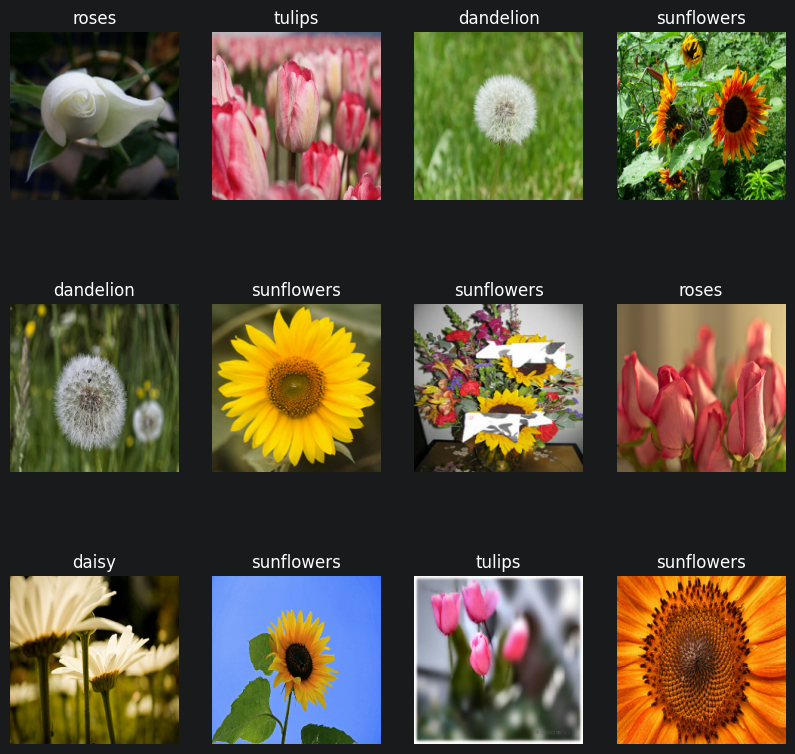

In [9]:
plt.figure(figsize=(10,10))  # optional
for image_batch, labels_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3,4,i+1)

        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.axis("off")
        plt.title(class_names[labels_batch[i]])

In [10]:
train_size = 0.8

In [11]:
def get_dataset_partitions(ds, train_size=0.8, val_size=0.1, test_size=0.1, shuffle=True, shuffle_size=100):
    assert(train_size + val_size + test_size == 1)


    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)

    train_size = int(train_size * ds_size)
    val_size = int(val_size * ds_size)
    test_size = int(test_size * ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(test_size).skip(val_size).take(test_size)

    return train_ds, val_ds, test_ds

In [12]:
train_ds, val_ds, test_ds  = get_dataset_partitions(dataset)

In [13]:
len(test_ds)

11

In [14]:
train_ds.cache().shuffle(100).prefetch(buffer_size = tf.data.AUTOTUNE)
val_ds.cache().shuffle(100).prefetch(buffer_size = tf.data.AUTOTUNE)
test_ds.cache().shuffle(100).prefetch(buffer_size = tf.data.AUTOTUNE)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [15]:
for image_batch, labels_batch in train_ds.take(1):
    print(image_batch[0].numpy()/255)

I0000 00:00:1788102810.455031    4399 shuffle_dataset_op.cc:453] ShuffleDatasetV3:10: Filling up shuffle buffer (this may take a while): 25 of 100
I0000 00:00:1788102820.707814    4399 shuffle_dataset_op.cc:453] ShuffleDatasetV3:10: Filling up shuffle buffer (this may take a while): 47 of 100
I0000 00:00:1788102830.872388    4399 shuffle_dataset_op.cc:453] ShuffleDatasetV3:10: Filling up shuffle buffer (this may take a while): 68 of 100


[[[0.48672438 0.48548403 0.47222114]
  [0.4782173  0.45134804 0.43803397]
  [0.44405183 0.4164104  0.4036149 ]
  ...
  [0.738209   0.7421306  0.71860117]
  [0.73443234 0.7383539  0.7148245 ]
  [0.7397147  0.74363625 0.72010684]]

 [[0.5146009  0.5170168  0.50192577]
  [0.48472193 0.46630454 0.4451672 ]
  [0.43214527 0.4131677  0.39190152]
  ...
  [0.7414065  0.74532807 0.72179866]
  [0.74027807 0.74419963 0.7206702 ]
  [0.7426821  0.74660367 0.72307426]]

 [[0.54196846 0.5393599  0.521971  ]
  [0.5032213  0.48310575 0.46030048]
  [0.43867657 0.41786432 0.39408803]
  ...
  [0.74587893 0.7481023  0.72542197]
  [0.7411765  0.74509805 0.72156864]
  [0.7426821  0.7435924  0.72156864]]

 ...

 [[0.29604065 0.29224867 0.15145695]
  [0.23019402 0.27657452 0.09742742]
  [0.30971077 0.3463372  0.14962639]
  ...
  [0.75379014 0.7577117  0.7335521 ]
  [0.7527285  0.75758284 0.733587  ]
  [0.745947   0.7577117  0.7302607 ]]

 [[0.28411567 0.2986182  0.13617362]
  [0.21448116 0.24988033 0.08739461]


I0000 00:00:1788102845.754649    4399 shuffle_dataset_op.cc:483] Shuffle buffer filled.


In [16]:
tf.keras.Sequential([
    layers.Resizing(IMG_SIZE, IMG_SIZE),
    layers.Rescaling(1.0/255),
])

<Sequential name=sequential, built=False>

In [17]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(IMG_SIZE, IMG_SIZE, IMG_CHANNELS)),
    keras.layers.Dense(len(CLASS_NAMES), activation="softmax")
])

# technically the model has no hidden layers
# it has only one layer which is corresponds to its pixel values or pixel intensity
# at keras.layers.Flatten(input_shape=(IMG_SIZE, IMG_SIZE, IMG_CHANNELS)), this flatten layer will have 224 * 224 * 3 perceptron nodes

/media/qs-ashish/DATA/ashish/core-python/.venv/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
model.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

In [19]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - accuracy: 0.3169 - loss: 5029.2183 - val_accuracy: 0.4403 - val_loss: 1569.3585
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.4008 - loss: 1960.1272 - val_accuracy: 0.4347 - val_loss: 1184.5598
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.4226 - loss: 1396.7545 - val_accuracy: 0.4943 - val_loss: 1537.5050
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.4588 - loss: 1382.6439 - val_accuracy: 0.4261 - val_loss: 2046.2407
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.4404 - loss: 2095.7476 - val_accuracy: 0.6023 - val_loss: 836.6949
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.5361 - loss: 1096.4614 - val_accuracy: 0.5625 - val_loss: 864.7039
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.5177 - loss: 1164.5554 - val_accuracy: 0.4943 - val_loss: 1316.2627
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.5031 

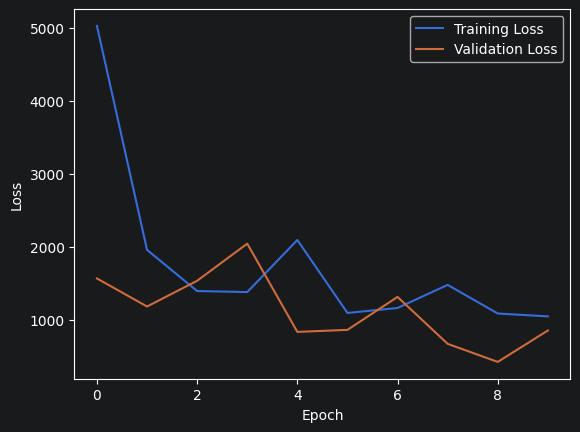

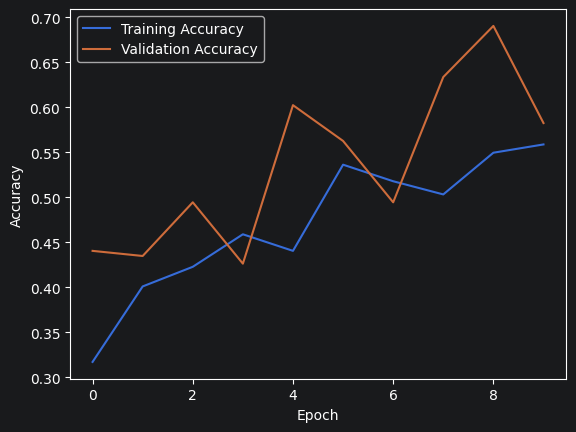

In [20]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [21]:
# more flutuations in the accuracy curve indicates that there is no better learning


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0050182343..254.92632].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.6428375..245.82867].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..254.77902].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.030017376..254.91966].
Clipping input data to 

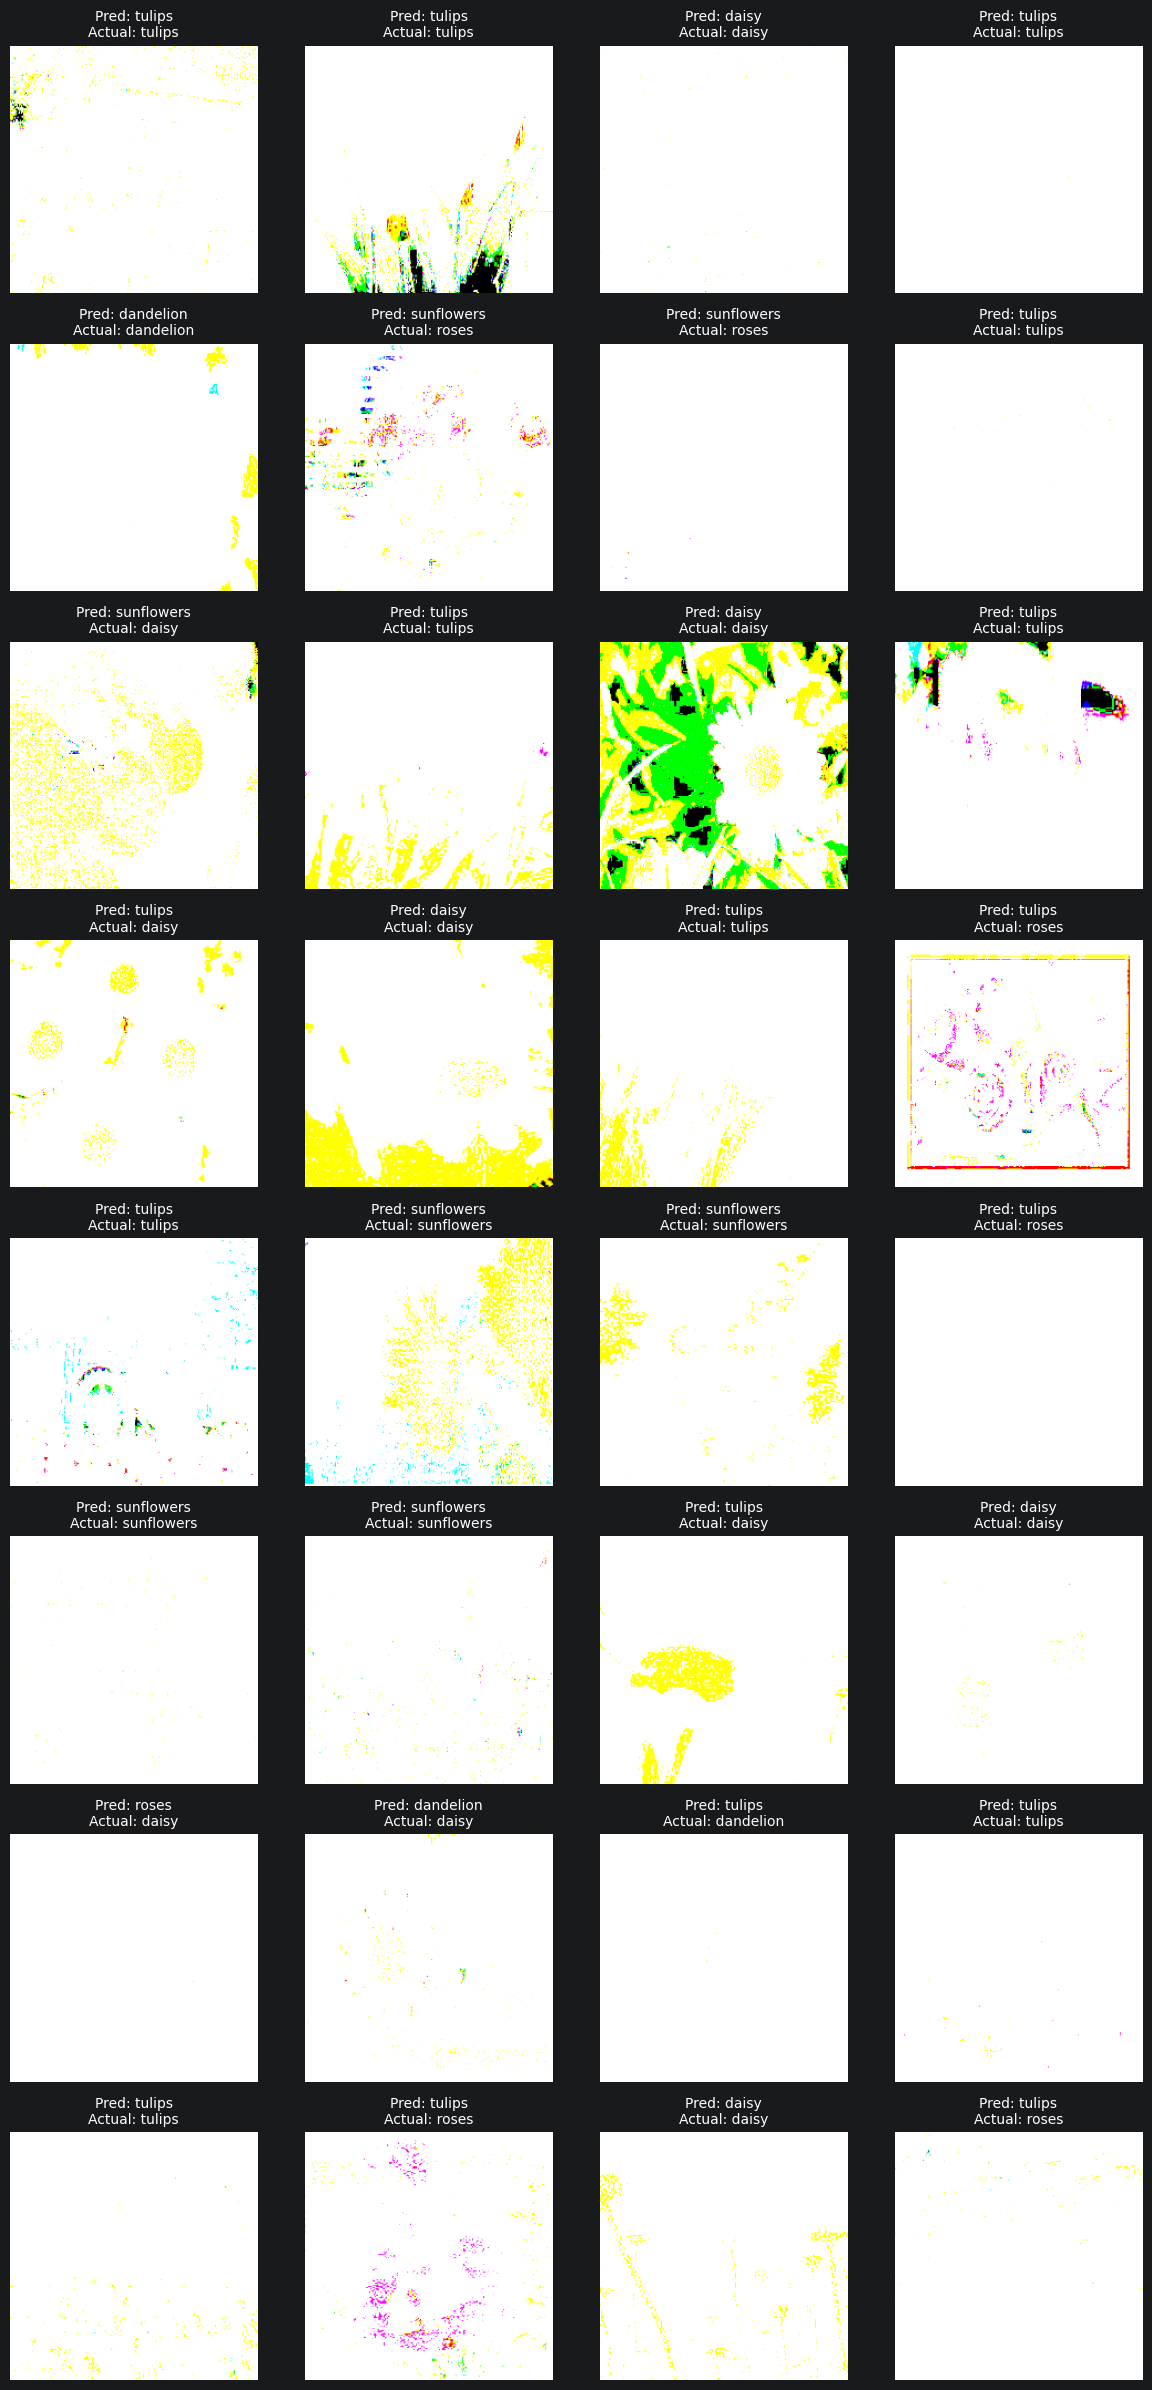

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Take exactly one batch from the evaluation dataset
for images, labels in val_ds.take(1):
    # Get model predictions for this batch
    batch_predictions = model.predict(images)
    predicted_indices = np.argmax(batch_predictions, axis=1)

    # Number of images in this batch
    num_images = images.shape[0]

    # Configure how many images to display per row
    num_cols = 4
    num_rows = math.ceil(num_images / num_cols)

    # Create a figure with a suitable size
    plt.figure(figsize=(12, 3 * num_rows))

    for i in range(num_images):
        plt.subplot(num_rows, num_cols, i + 1)

        # Display the image
        plt.imshow(images[i].numpy())
        plt.axis('off')

        # Get predicted and actual class names
        pred_class = CLASS_NAMES[predicted_indices[i]]
        actual_class = CLASS_NAMES[labels[i].numpy()]

        # Show both predicted and actual labels as title
        plt.title(f"Pred: {pred_class}\nActual: {actual_class}", fontsize=10)

    # Adjust spacing to avoid overlapping titles, etc.
    plt.tight_layout()
    plt.show()

In [23]:
# more fluctuations i

## Slighly better Neural network with two hidden layers

In [27]:
# we have one flatten layer and one hidden layer
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(IMG_SIZE, IMG_SIZE, IMG_CHANNELS)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(len(CLASS_NAMES), activation="softmax"),
])

In [28]:
model.compile(
    # optimizer="adam",    # this uses default learning rate = 0.001
    optimizer = keras.optimizers.Adam(learning_rate=0.05), # use this synatx if we wants to mention learning rate as well

    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

In [26]:
# https://www.geeksforgeeks.org/deep-learning/why-relu-function-is-not-differentiable-at-x-0/
# relu function is continous but not differntiable at x = 0

In [29]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 154ms/step - accuracy: 0.3108 - loss: 4161.8564 - val_accuracy: 0.3153 - val_loss: 48.7610
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 157ms/step - accuracy: 0.2195 - loss: 2.9445 - val_accuracy: 0.2415 - val_loss: 1.6065
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 154ms/step - accuracy: 0.2314 - loss: 1.6066 - val_accuracy: 0.2472 - val_loss: 1.6064
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 157ms/step - accuracy: 0.2485 - loss: 1.6046 - val_accuracy: 0.2528 - val_loss: 1.6043
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 158ms/step - accuracy: 0.2437 - loss: 1.6039 - val_accuracy: 0.2719 - val_loss: 1.5954
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 16s 156ms/step - accuracy: 0.2457 - loss: 1.6018 - val_accuracy: 0.2727 - val_loss: 1.5998
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 151ms/step - accuracy: 0.2500 - loss: 1.6001 - val_accuracy: 0.2585 - val_loss: 1.5979
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 154ms/step - accuracy: 0.2509 - loss: 1.6003 - val_

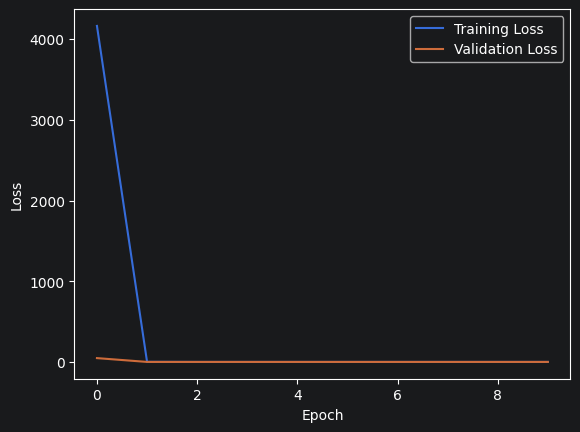

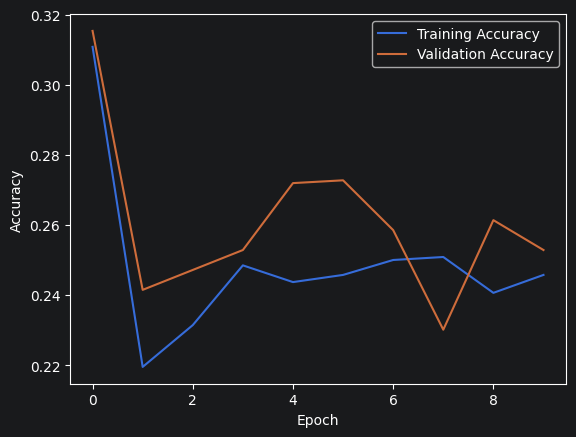

In [30]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [31]:
# hyperparametrs
# 1. Learning rate
# 2. Image size
# 3. Batch size
# 4. optimisers
# 5. number of epochs
# 6. Loss function
# 7. number of hiiden layers
# 8. numer of neurons in each layers

# Parametrs
# 1. Weight
# 2. Biase

# Note: when we train a neural network then we train to obtain the best (optimal weight and biases) but when we search for the NN architecture then we look for the hyperparameters

## if we wants to define

In [1]:
# adding regularazation layer

In [2]:
from tensorflow.keras.regularizers import l1_l2

regularizers = l1_l2(0, 0.001)
# lambda for l1 reguliser is 0
# lambda for l2 regulasier is 0.01
# means we are just using l2 reguliser

I0000 00:00:1788271729.614257    4451 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788271729.646399    4451 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788271733.918843    4451 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788271771.483701    4451 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [ ]:

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(IMG_SIZE, IMG_SIZE, IMG_CHANNELS)),
    keras.layers.Dense(128, kernel_regularizer=regularizers,activation="relu"),
    keras.layers.Dense(len(CLASS_NAMES), activation="softmax"),
])


# kernel_regularizer parameter is used for the regularization layer adding